# 🏎️ F1 Team Radio NLP Analyzer
**HS Aalen — NLP Course Project**

*Applied Natural Language Processing pipeline on real Formula 1 Team Radio communications.*

### Project Overview
This Jupyter notebook presents a complete end-to-end NLP pipeline applied to real F1 team radio transcripts scraped from AutoLAP (`transcripts.recursiveprojects.cloud`). It covers 13 distinct computational phases:
1. **Web Crawling & BeautifulSoup Scraping**
2. **Vocabulary Stats, Zipf's Law & Luhn's Cuts**
3. **Sparse CSR/CSC Matrices & Memory Benchmarks**
4. **Text Tokenization, Stemming & Lemmatization**
5. **Vectorization & Numerical Feature Representation (One-Hot, Count & TF-IDF)**
6. **Category Classification & Custom Sentiment Lexicon**
7. **Custom CBOW Word Embeddings in PyTorch**
8. **Feed-Forward Neural Network Classifier (PyTorch MLP)**
9. **POS Dependency Grammar & Sequence Models (RNN / LSTM in PyTorch)**
10. **spaCy Custom Pipeline Components & Intent Matchers**
11. **Custom Named Entity Recognition (NER) Model Training**
12. **Trigram Text Synthesizer & Pattern Matching Chatbot**
13. **Multi-Source Retrieval-Augmented Generation (RAG) System**

---
**Course:** Natural Language Processing (NLP)  
**University:** Hochschule Aalen  
**Student:** Shashwat Singh (M.Sc. Machine Learning and Data Analytics, Hochschule Aalen)  
**Date:** June 2026


## Imports & Setup
We import all necessary libraries used across the modules.

In [1]:
import os
import time
import sys
import math
import random
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
import networkx as nx

# NLP & ML
import sklearn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from scipy.sparse import csr_matrix, csc_matrix

# NLTK
import nltk
from nltk.stem import PorterStemmer

# spaCy
import spacy
from spacy.matcher import Matcher
from spacy.tokens import Span
from spacy.util import filter_spans

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Matplotlib styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

# Device configuration for PyTorch
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"Using device: {device}")


Using device: mps


## Phase 1 — Web Crawling & Scraping (BeautifulSoup)
In this module, we:
1. Parse and display `robots.txt` from the data source to ensure ethical scraping.
2. Implement a 3-level web crawler using `requests` and `BeautifulSoup` to scrape transcripts.
3. Build a directed web graph using `NetworkX` representing the crawling path.
4. Load the crawled dataset and present basic corpus statistics.


In [2]:
# 1.1 Ethical Web Scraping & robots.txt
url_robots = "https://transcripts.recursiveprojects.cloud/robots.txt"
try:
    res = requests.get(url_robots, timeout=5)
    print("--- robots.txt content ---")
    print(res.text)
except Exception as e:
    print("Could not fetch robots.txt:", e)


--- robots.txt content ---
# See https://www.robotstxt.org/robotstxt.html for documentation on how to use the robots.txt file
#
# To ban all spiders from the entire site uncomment the next two lines:
# User-agent: *
# Disallow: /



In [3]:
# 1.2 Web Crawler Implementation
# The BeautifulSoup crawler fetches /archive, lists sessions, then fetches driver pages to extract radio messages.
# We set SCRAPE_FROM_WEB = False by default because we have already pre-scraped and saved the corpus to save time.

SCRAPE_FROM_WEB = False
CSV_PATH = "data/processed/f1_radio_corpus.csv"

def scrape_f1_data():
    base_url = "https://transcripts.recursiveprojects.cloud"
    headers = {"User-Agent": "F1-NLP-Course-Project/1.0"}
    all_messages = []
    
    # 1. Fetch archive
    res = requests.get(f"{base_url}/archive", headers=headers)
    soup = BeautifulSoup(res.text, "html.parser")
    session_links = soup.find_all("a", href=lambda x: x and x.startswith("/archive/"))
    
    # Let's scrape just 1 session for demonstration purposes
    target_sessions = []
    for link in session_links:
        name = link.get_text(strip=True)
        if name.endswith("Grand Prix") and not any(k in name for k in ["Qualifying", "Practice", "Sprint"]):
            target_sessions.append((name, f"{base_url}{link.get('href')}"))
            if len(target_sessions) >= 1: # Limit to 1 for demo
                break
                
    for sess_name, sess_url in target_sessions:
        print(f"Scraping session: {sess_name}")
        res_sess = requests.get(sess_url, headers=headers)
        soup_sess = BeautifulSoup(res_sess.text, "html.parser")
        driver_links = soup_sess.find_all("a", href=lambda x: x and x.startswith(sess_url.replace(base_url, "")))
        
        # Scrape messages for first 3 drivers only in this demo crawler
        for drv_link in driver_links[:3]:
            drv_name = drv_link.get_text(strip=True)
            drv_url = f"{base_url}{drv_link.get('href')}"
            
            # Ensure it's a driver detail link
            if len(drv_link.get('href').strip("/").split("/")) == 3:
                print(f"  Scraping driver: {drv_name}")
                time.sleep(1.0) # Respectful delay
                res_drv = requests.get(drv_url, headers=headers)
                soup_drv = BeautifulSoup(res_drv.text, "html.parser")
                
                message_divs = soup_drv.find_all("div", class_=lambda x: x and "dark:bg-zinc-800" in x)
                for div in message_divs:
                    ts_span = div.find("span", class_="timestamp")
                    ts = ts_span.get("data-timestamp") if ts_span else None
                    grow_div = div.find(class_="grow")
                    msg = grow_div.get_text(strip=True) if grow_div else None
                    if msg:
                        all_messages.append({
                            "grand_prix": sess_name,
                            "session_type": "Race",
                            "driver_name": drv_name,
                            "timestamp": ts,
                            "message_text": msg
                        })
    return pd.DataFrame(all_messages)

if SCRAPE_FROM_WEB:
    print("Crawling Live Data...")
    df = scrape_f1_data()
    df.to_csv(CSV_PATH, index=False)
else:
    print("Loading data from pre-scraped CSV...")
    if os.path.exists(CSV_PATH):
        df = pd.read_csv(CSV_PATH)
    else:
        raise FileNotFoundError(f"Corpus file not found at {CSV_PATH}. Please run the scraper first.")

print(f"Loaded corpus with {len(df)} radio messages.")
df.head()


Loading data from pre-scraped CSV...
Loaded corpus with 18574 radio messages.


,grand_prix,session_type,driver_name,timestamp,message_text
0,2026 Barcelona-Catalunya Grand Prix,Race,Alexander Albon,2026-06-14T12:52:46.360000Z,Radio check.
1,2026 Barcelona-Catalunya Grand Prix,Race,Alexander Albon,2026-06-14T12:52:47.618000Z,Check. You're allowed extra hit.
2,2026 Barcelona-Catalunya Grand Prix,Race,Alexander Albon,2026-06-14T12:52:51.650000Z,"Check, so I can't..."
3,2026 Barcelona-Catalunya Grand Prix,Race,Alexander Albon,2026-06-14T12:57:59.106000Z,"OK, tyres, it's just..."
4,2026 Barcelona-Catalunya Grand Prix,Race,Alexander Albon,2026-06-14T12:57:59.832000Z,"Tyres, I mean, it's just over two minutes to go."


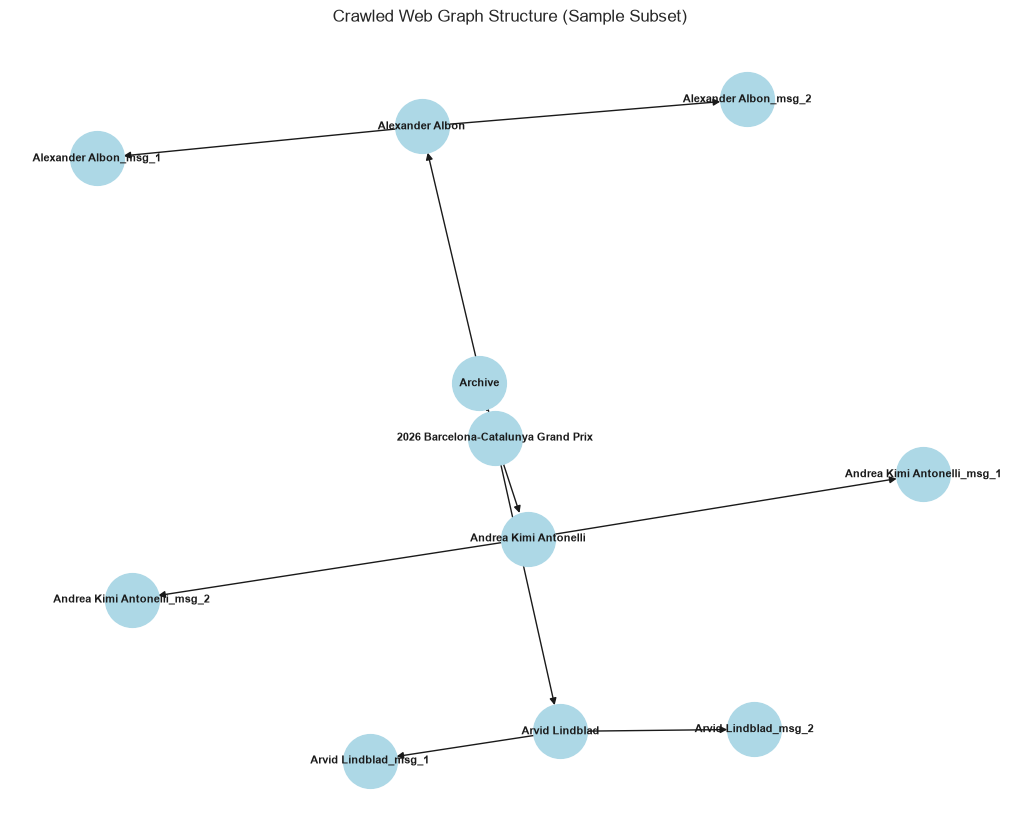

In [4]:
# 1.3 Directed Web Graph of the Scraped Structure
# Model the hierarchical crawling path: Archive -> Sessions -> Drivers -> Messages
G = nx.DiGraph()

# Add root node
G.add_node("Archive", type="root")

# Sample a small subset of 1 Grand Prix session, 3 drivers, and 2 messages each to visualize
sample_gps = df["grand_prix"].unique()[:1]
for gp in sample_gps:
    G.add_edge("Archive", gp)
    df_gp = df[df["grand_prix"] == gp]
    sample_drivers = df_gp["driver_name"].unique()[:3]
    for drv in sample_drivers:
        G.add_edge(gp, drv)
        df_drv = df_gp[df_gp["driver_name"] == drv]
        for i, msg in enumerate(df_drv["message_text"].iloc[:2]):
            node_name = f"{drv}_msg_{i+1}"
            G.add_edge(drv, node_name)

# Visualize directed graph
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=1500, node_color="lightblue", font_size=8, font_weight="bold", arrows=True)
plt.title("Crawled Web Graph Structure (Sample Subset)")
plt.show()


Total radio messages: 18574
Unique Grand Prix sessions: 3
Unique drivers: 22

Drivers in dataset:
<ArrowStringArray>
[      'Alexander Albon', 'Andrea Kimi Antonelli',        'Arvid Lindblad',
          'Carlos Sainz',       'Charles Leclerc',          'Esteban Ocon',
       'Fernando Alonso',      'Franco Colapinto',     'Gabriel Bortoleto',
        'George Russell',          'Isack Hadjar',          'Lance Stroll',
          'Lando Norris',        'Lewis Hamilton',           'Liam Lawson',
        'Max Verstappen',       'Nico Hulkenberg',        'Oliver Bearman',
         'Oscar Piastri',          'Pierre Gasly',          'Sergio Perez',
       'Valtteri Bottas']
Length: 22, dtype: str

Average message length (words): 6.48
Max message length (words): 149


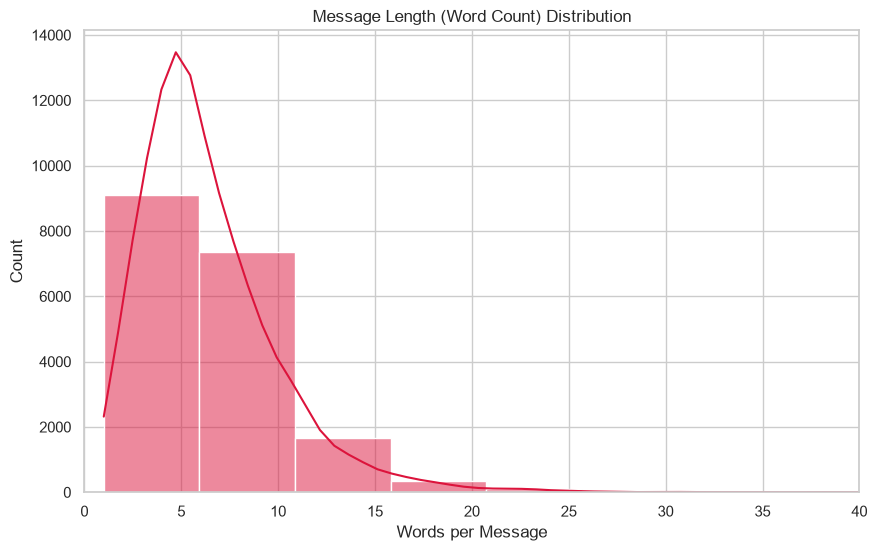

In [5]:
# 1.4 Data Overview and Basic Corpus Statistics
print(f"Total radio messages: {len(df)}")
print(f"Unique Grand Prix sessions: {df['grand_prix'].nunique()}")
print(f"Unique drivers: {df['driver_name'].nunique()}")
print("\nDrivers in dataset:")
print(df["driver_name"].unique())

# Length distribution of messages
df["message_len"] = df["message_text"].apply(lambda x: len(str(x).split()))
print(f"\nAverage message length (words): {df['message_len'].mean():.2f}")
print(f"Max message length (words): {df['message_len'].max()}")

# Plot distribution
sns.histplot(df["message_len"], bins=30, kde=True, color="crimson")
plt.title("Message Length (Word Count) Distribution")
plt.xlabel("Words per Message")
plt.ylabel("Count")
plt.xlim(0, 40)
plt.show()


## Phase 2 — Vocabulary Stats, Zipf's Law & Luhn's Cuts
In this module, we:
1. Verify Zipf's Law on the F1 team radio corpus.
2. Discuss Luhn's operational bounds and Shannon Entropy.
3. Build a Bag of Words representation.
4. Implement a TF-IDF vectorizer and a search engine from scratch.


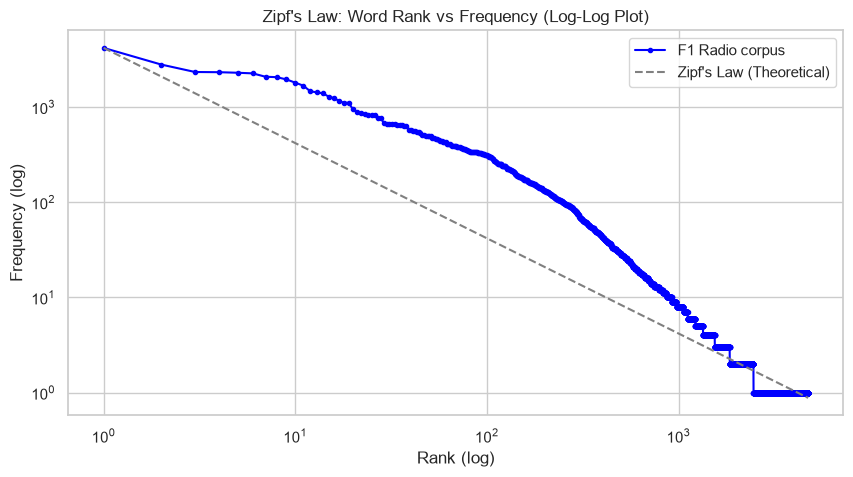

Top 25 words in F1 Radio:
  the: 4178
  to: 2791
  i: 2332
  you: 2321
  s: 2290
  we: 2256
  and: 2078
  go: 2059
  a: 1948
  on: 1800
  it: 1678
  is: 1459
  that: 1427
  turn: 1388
  one: 1279
  for: 1240
  in: 1148
  so: 1109
  at: 1108
  of: 944
  behind: 885
  car: 870
  have: 842
  b: 832
  can: 827


In [6]:
# 2.1 Zipf's Law Verification
from collections import Counter
import re

# Tokenize all messages
all_text = " ".join(df["message_text"].astype(str).tolist()).lower()
words = re.findall(r'\b\w+\b', all_text)
word_counts = Counter(words)

# Frequency ranking
sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)
ranks = np.arange(1, len(sorted_words) + 1)
frequencies = np.array([count for word, count in sorted_words])

# Plotting Rank vs Frequency (Log-Log)
plt.figure(figsize=(10, 5))
plt.loglog(ranks, frequencies, marker=".", color="blue", label="F1 Radio corpus")
# Zipf theoretical baseline (f = c / r)
plt.loglog(ranks, frequencies[0] / ranks, linestyle="--", color="gray", label="Zipf's Law (Theoretical)")
plt.title("Zipf's Law: Word Rank vs Frequency (Log-Log Plot)")
plt.xlabel("Rank (log)")
plt.ylabel("Frequency (log)")
plt.legend()
plt.show()

# Show top 25 words
print("Top 25 words in F1 Radio:")
for w, c in sorted_words[:25]:
    print(f"  {w}: {c}")


In [7]:
# 2.2 Shannon Entropy and Luhn's Significance Bounds
# Shannon Entropy: H(X) = -sum(P(x) * log2(P(x)))
total_words = len(words)
probabilities = [count / total_words for word, count in sorted_words]
entropy = -sum(p * math.log2(p) for p in probabilities)
print(f"Shannon Entropy of F1 Radio vocabulary: {entropy:.4f} bits\n")

# Luhn's analysis: Significant words lie in the middle region of the frequency curve.
# Words that are too frequent (stopwords) and too rare (hapax legomena) contain little information.
print("Luhn Cut Zones:")
print(f"High-frequency cut-off (top 15 words excluded):")
print([w for w, _ in sorted_words[:15]])
print("\nLow-frequency cut-off (words occurring only once excluded):")
rare_words = [w for w, c in sorted_words if c == 1]
print(f"Excluded {len(rare_words)} rare words (Hapax Legomena) out of {len(sorted_words)} total vocabulary size.")


Shannon Entropy of F1 Radio vocabulary: 8.7776 bits

Luhn Cut Zones:
High-frequency cut-off (top 15 words excluded):
['the', 'to', 'i', 'you', 's', 'we', 'and', 'go', 'a', 'on', 'it', 'is', 'that', 'turn', 'one']

Low-frequency cut-off (words occurring only once excluded):
Excluded 2288 rare words (Hapax Legomena) out of 4747 total vocabulary size.


In [8]:
# 2.3 TF-IDF Search Engine from Scratch
# Step 1: Compute TF (Term Frequency) - Normalized by message length
def compute_tf(doc):
    tokens = doc.lower().split()
    counts = Counter(tokens)
    tf = {}
    doc_len = len(tokens)
    if doc_len == 0:
        return tf
    for word, count in counts.items():
        tf[word] = count / doc_len
    return tf

# Step 2: Compute IDF (Inverse Document Frequency)
def compute_idf(corpus):
    n_docs = len(corpus)
    idf = {}
    all_words = set()
    doc_word_sets = []
    
    for doc in corpus:
        tokens = set(str(doc).lower().split())
        doc_word_sets.append(tokens)
        all_words.update(tokens)
        
    for word in all_words:
        n_containing = sum(1 for doc_set in doc_word_sets if word in doc_set)
        # Using smooth IDF formula: ln(N / (df + 1)) + 1
        idf[word] = math.log(n_docs / (n_containing + 1)) + 1
    return idf

# Step 3: Compute TF-IDF
def compute_tfidf(doc, idf_dict):
    tf = compute_tf(doc)
    tfidf = {}
    for word, tf_val in tf.items():
        if word in idf_dict:
            tfidf[word] = tf_val * idf_dict[word]
    return tfidf

# Precompute IDF for F1 corpus
corpus = df["message_text"].astype(str).tolist()
idf_dict = compute_idf(corpus)

# Step 4: Search Engine Function using Cosine Similarity
def search_scratch(query, k=5):
    query_tfidf = compute_tfidf(query, idf_dict)
    if not query_tfidf:
        return pd.DataFrame()
        
    scores = []
    for idx, doc in enumerate(corpus):
        doc_tfidf = compute_tfidf(doc, idf_dict)
        # Calculate dot product
        dot_product = 0.0
        for word, val in query_tfidf.items():
            if word in doc_tfidf:
                dot_product += val * doc_tfidf[word]
                
        # Magnitudes
        q_mag = math.sqrt(sum(v**2 for v in query_tfidf.values()))
        doc_mag = math.sqrt(sum(v**2 for v in doc_tfidf.values()))
        
        sim = 0.0
        if q_mag > 0 and doc_mag > 0:
            sim = dot_product / (q_mag * doc_mag)
            
        if sim > 0:
            scores.append((idx, sim))
            
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[:k]
    
    results = []
    for idx, score in scores:
        results.append({
            "driver": df.iloc[idx]["driver_name"],
            "gp": df.iloc[idx]["grand_prix"],
            "message": df.iloc[idx]["message_text"],
            "similarity": score
        })
    return pd.DataFrame(results)

# Test search engine
print("--- Search Result for: 'box box pit stop' ---")
search_scratch("box box pit stop")


--- Search Result for: 'box box pit stop' ---


,driver,gp,message,similarity
0,Lance Stroll,2026 Canadian Grand Prix,"Box now, go box now.",0.659822
1,Lance Stroll,2026 Monaco Grand Prix,"Box now. Box now, Lance. Box now.",0.656089
2,Esteban Ocon,2026 Canadian Grand Prix,Box now.,0.640507
3,Esteban Ocon,2026 Canadian Grand Prix,On box now. Box now.,0.624787
4,Lance Stroll,2026 Canadian Grand Prix,"Box now, Lance, box now.",0.616699


## Phase 3 — Sparse CSR/CSC Matrices & Memory Benchmarks
Most entries in a document-term matrix are zero. Storing them as a dense matrix is inefficient. Here, we:
1. Re-represent our manual TF-IDF matrix.
2. Benchmark memory usage of Dense vs. Sparse representations.
3. Compare CSR (Compressed Sparse Row) and CSC (Compressed Sparse Column) formats.
4. Visualize matrix sparsity pattern using `spy()`.


In [9]:
# 3.1 Sparse vs Dense Representation Memory Benchmark
from scipy.sparse import csr_matrix

# Build scikit-learn TF-IDF Matrix (comparable to our scratch implementation)
vectorizer = TfidfVectorizer(token_pattern=r'(?u)\b\w+\b')
sparse_matrix = vectorizer.fit_transform(df["message_text"].astype(str))
dense_matrix = sparse_matrix.toarray()

# Memory calculation
sparse_bytes = sparse_matrix.data.nbytes + sparse_matrix.indptr.nbytes + sparse_matrix.indices.nbytes
dense_bytes = dense_matrix.nbytes

print(f"Matrix shape: {sparse_matrix.shape}")
print(f"Sparse (CSR) Matrix Memory: {sparse_bytes / 1024:.2f} KB")
print(f"Dense Matrix Memory: {dense_bytes / 1024:.2f} KB")
print(f"Memory Savings Ratio: {dense_bytes / sparse_bytes:.1f}x")


Matrix shape: (18574, 4747)
Sparse (CSR) Matrix Memory: 1450.65 KB
Dense Matrix Memory: 688834.20 KB
Memory Savings Ratio: 474.8x


In [10]:
# 3.2 CSR vs CSC Benchmarking
import time

csr_mat = sparse_matrix.tocsr()
csc_mat = sparse_matrix.tocsc()

# Benchmark row slicing (common in retrieval/classification)
t0 = time.time()
for i in range(min(1000, csr_mat.shape[0])):
    _ = csr_mat[i, :]
t_row_csr = time.time() - t0

t0 = time.time()
for i in range(min(1000, csc_mat.shape[0])):
    _ = csc_mat[i, :]
t_row_csc = time.time() - t0

# Benchmark column slicing (common in keyword/feature analysis)
t0 = time.time()
for j in range(min(200, csr_mat.shape[1])):
    _ = csr_mat[:, j]
t_col_csr = time.time() - t0

t0 = time.time()
for j in range(min(200, csc_mat.shape[1])):
    _ = csc_mat[:, j]
t_col_csc = time.time() - t0

print(f"CSR Row Slicing: {t_row_csr*1000:.2f} ms | CSC Row Slicing: {t_row_csc*1000:.2f} ms")
print(f"CSR Column Slicing: {t_col_csr*1000:.2f} ms | CSC Column Slicing: {t_col_csc*1000:.2f} ms")


CSR Row Slicing: 21.78 ms | CSC Row Slicing: 138.51 ms
CSR Column Slicing: 86.84 ms | CSC Column Slicing: 4.17 ms


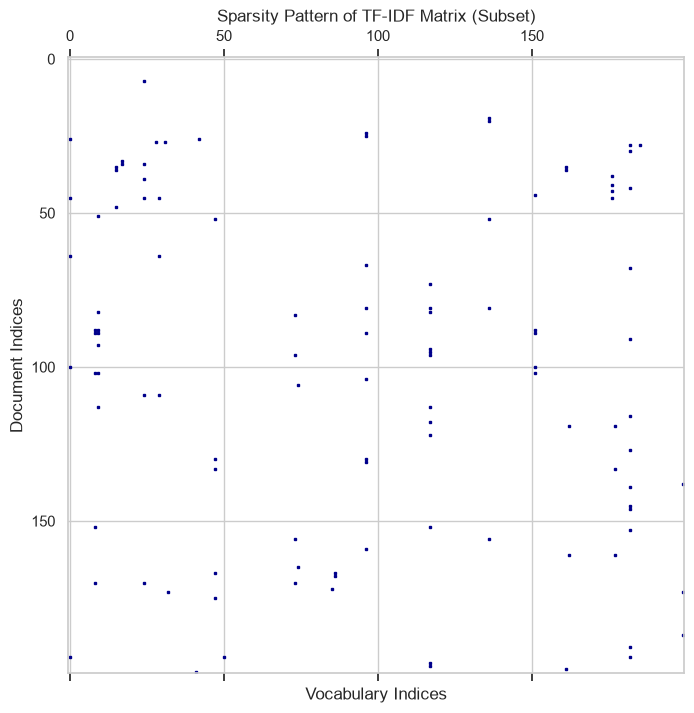

Matrix Sparsity Score: 99.8666% (Only 0.1334% of entries are non-zero)


In [11]:
# 3.3 Matrix Sparsity Visualization (spy)
plt.figure(figsize=(10, 8))
# Plot the sparsity pattern of the first 200 documents and first 200 vocabulary terms
plt.spy(sparse_matrix[:200, :200], markersize=1.5, color='darkblue')
plt.title("Sparsity Pattern of TF-IDF Matrix (Subset)")
plt.xlabel("Vocabulary Indices")
plt.ylabel("Document Indices")
plt.show()

sparsity = 1.0 - (sparse_matrix.nnz / (sparse_matrix.shape[0] * sparse_matrix.shape[1]))
print(f"Matrix Sparsity Score: {sparsity*100:.4f}% (Only {100.0 - sparsity*100:.4f}% of entries are non-zero)")


## Phase 4 — Text Tokenization, Stemming & Lemmatization
In this module, we implement:
1. Advanced tokenization via spaCy and examine F1-specific tokens.
2. Stopword removal, Stemming (Porter), and Lemmatization (spaCy).
3. Customized `spaCy` Matcher rules to extract Formula 1 patterns (pit calls, gaps, modes, tire compounds).
4. Rebuild the search engine with NLP preprocessing.


In [12]:
# 4.1 Tokenization, Stemming vs Lemmatization
nlp = spacy.load("en_core_web_sm")
stemmer = PorterStemmer()

sample_message = "Verstappen is box box this lap. Check tire degradation and gap behind Hamilton, current gap is 1.8 seconds."

# 1. spaCy Tokenization & Lemmatization
doc = nlp(sample_message)
print(f"{'Token':<18} | {'Stem (Porter)':<15} | {'Lemma (spaCy)':<15}")
print("-" * 55)
for token in list(doc)[:10]:
    stem = stemmer.stem(token.text)
    print(f"{token.text:<18} | {stem:<15} | {token.lemma_:<15}")


Token              | Stem (Porter)   | Lemma (spaCy)  
-------------------------------------------------------
Verstappen         | verstappen      | Verstappen     
is                 | is              | be             
box                | box             | box            
box                | box             | box            
this               | thi             | this           
lap                | lap             | lap            
.                  | .               | .              
Check              | check           | check          
tire               | tire            | tire           
degradation        | degrad          | degradation    


In [13]:
# 4.2 Custom Token Matchers for F1 Jargon
# We build spaCy Matcher rules to identify lap times, gap reports, pit calls, modes/strategies, tire compounds, and positions.
matcher = Matcher(nlp.vocab)

# Add F1 patterns
matcher.add("PIT_CALL", [[{"LOWER": "box"}, {"LOWER": "box"}]])
matcher.add("GAP_REPORT", [[{"LOWER": "gap"}, {"LIKE_NUM": True}]])
matcher.add("TIRE_COMPOUND", [[{"LOWER": {"IN": ["soft", "medium", "hard", "softs", "mediums", "hards", "inter", "inters", "intermediate", "wet", "wets"]}}]])
matcher.add("STRAT_MODE", [[{"LOWER": {"IN": ["mode", "strat"]}}, {"LIKE_NUM": True}]])
matcher.add("LAP_TIME", [[{"TEXT": {"REGEX": r'^\d+:\d+\.\d+$'}}, {"TEXT": {"REGEX": r'^\d+\.\d+$'}}]])
matcher.add("POSITION", [[{"TEXT": {"REGEX": r'^[pP]\d+$'}}]])

doc_f1 = nlp("Alright Lewis, box box. Max is running medium tires, mode 7, gap is 5.4. Russell is currently P3.")
matches = matcher(doc_f1)

print("Detected F1 Jargon:")
for match_id, start, end in matches:
    string_id = nlp.vocab.strings[match_id]
    span = doc_f1[start:end]
    print(f"  {string_id:<15} -> {span.text}")


Detected F1 Jargon:
  PIT_CALL        -> box box
  TIRE_COMPOUND   -> medium
  STRAT_MODE      -> mode 7
  POSITION        -> P3


In [14]:
# 4.3 Rebuilding the Search Engine with NLP Preprocessing
# We preprocess all documents (lemmatize, remove stopwords and punctuation) and test the search engine.
def preprocess_text(text):
    doc = nlp(str(text).lower())
    # Keep alphanumeric words, remove stopwords & punctuation
    tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and len(token.text) > 1]
    return " ".join(tokens)

# Preprocess corpus
df["clean_message"] = df["message_text"].apply(preprocess_text)

# Build improved search engine
vectorizer_clean = TfidfVectorizer()
tfidf_clean = vectorizer_clean.fit_transform(df["clean_message"])

def search_improved(query, k=5):
    query_clean = preprocess_text(query)
    q_vec = vectorizer_clean.transform([query_clean])
    
    # Cosine similarities
    from sklearn.metrics.pairwise import cosine_similarity
    sims = cosine_similarity(q_vec, tfidf_clean).flatten()
    
    top_indices = sims.argsort()[::-1][:k]
    results = []
    for idx in top_indices:
        if sims[idx] > 0:
            results.append({
                "driver": df.iloc[idx]["driver_name"],
                "gp": df.iloc[idx]["grand_prix"],
                "message": df.iloc[idx]["message_text"],
                "clean_msg": df.iloc[idx]["clean_message"],
                "similarity": sims[idx]
            })
    return pd.DataFrame(results)

print("--- Improved Search Result for: 'box box pit stop' ---")
search_improved("box box pit stop")


--- Improved Search Result for: 'box box pit stop' ---


,driver,gp,message,clean_msg,similarity
0,Oscar Piastri,2026 Canadian Grand Prix,The bottom of the pit box.,pit box,0.866593
1,Oscar Piastri,2026 Monaco Grand Prix,Back into the pits. You're boxing.,pit box,0.866593
2,Sergio Perez,2026 Monaco Grand Prix,"Box this lap. Box, box, box. Pit confirm.",box lap box box box pit confirm,0.839139
3,Sergio Perez,2026 Monaco Grand Prix,"Box, box, box. Pit confirm.",box box box pit confirm,0.836603
4,Charles Leclerc,2026 Barcelona-Catalunya Grand Prix,And box.,box,0.818165


## Phase 5 — Vectorization & Numerical Feature Representation
We learn numerical representations for unstructured text:
1. One-Hot encoding for categorical data (e.g. driver name, session type).
2. CountVectorizer (Bag of Words) to represent vocabulary.
3. TF-IDF Vectorizer from scikit-learn.


In [15]:
# 5.1 One-Hot Encoding on driver names
lb = LabelBinarizer()
one_hot_drivers = lb.fit_transform(df["driver_name"])
print("One-Hot Encoded drivers matrix shape:", one_hot_drivers.shape)
print("Example representation for:", df["driver_name"].iloc[0])
print(one_hot_drivers[0])


One-Hot Encoded drivers matrix shape: (18574, 22)
Example representation for: Alexander Albon
[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [16]:
# 5.2 CountVectorizer vs TF-IDF Vectorizer
count_vec = CountVectorizer(max_features=1000)
bow_matrix = count_vec.fit_transform(df["clean_message"])

tfidf_vec = TfidfVectorizer(max_features=1000)
tfidf_matrix = tfidf_vec.fit_transform(df["clean_message"])

print(f"Bag of Words Matrix Shape: {bow_matrix.shape}")
print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")

# Vocabulary example
vocab = tfidf_vec.vocabulary_
print("Sample vocabulary mapping (word -> index):")
sample_vocab = list(vocab.items())[:15]
for w, idx in sample_vocab:
    print(f"  {w:<15} -> {idx}")


Bag of Words Matrix Shape: (18574, 1000)


TF-IDF Matrix Shape: (18574, 1000)
Sample vocabulary mapping (word -> index):
  radio           -> 712
  check           -> 170
  allow           -> 76
  extra           -> 291
  hit             -> 408
  ok              -> 592
  tyre            -> 934
  mean            -> 539
  minute          -> 561
  let             -> 479
  car             -> 157
  ahead           -> 72
  ocon            -> 588
  soft            -> 823
  13              -> 6


## Phase 6 — Category Classification & Custom Sentiment Lexicon
In this module, we:
1. Automatically label our radio dataset using keyword heuristics.
2. Train multiple Classifiers (Naive Bayes, Logistic Regression, Linear SVM).
3. Evaluate classifications using Precision, Recall, and Confusion Matrices.
4. Implement rule-based Sentiment Intensity Scoring to locate frustrated, urgent, or celebratory messages.


Category Distribution:
category
Technical       10496
Position_Gap     3592
Strategy         2551
Emotional        1935
Name: count, dtype: int64


/var/folders/_w/j206vlqj7cs96wnwqqpkj57m0000gp/T/ipykernel_81288/3024896087.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["category"], palette="viridis")


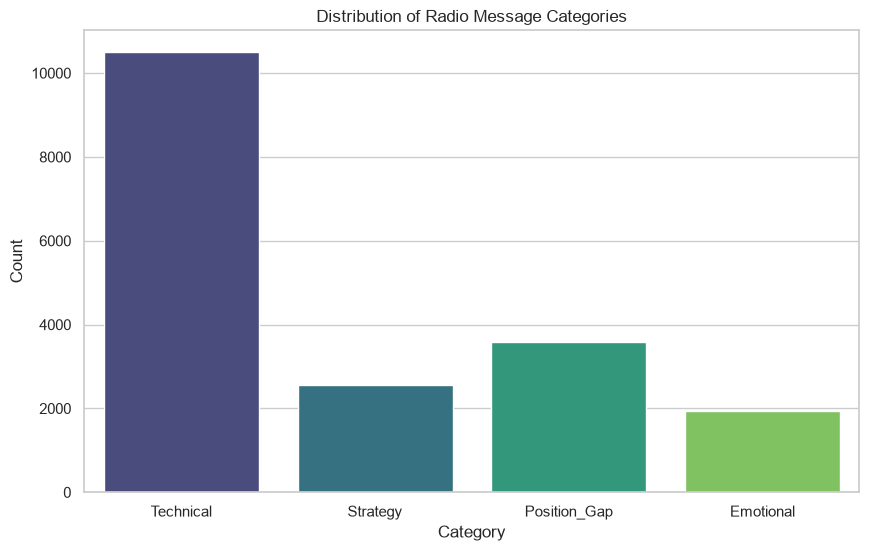

In [17]:
# 6.1 Keyword-based Heuristics Label Creation
def assign_category(text):
    text_lower = str(text).lower()
    if any(k in text_lower for k in ["box", "pit", "strat", "mode", "charge", "entry", "tyre", "soft", "medium", "hard", "hards", "softs", "mediums"]):
        return "Strategy"
    elif any(k in text_lower for k in ["gap", "behind", "ahead", "interval", "pace", "lap", "p1", "p2", "p3", "position", "sec", "seconds"]):
        return "Position_Gap"
    elif any(k in text_lower for k in ["f**k", "fuck", "shout", "angry", "screaming", "no", "what", "why", "impossible", "mate", "!", "unbelievable"]):
        return "Emotional"
    else:
        return "Technical"

df["category"] = df["message_text"].apply(assign_category)
print("Category Distribution:")
print(df["category"].value_counts())

# Plot distribution
sns.countplot(x=df["category"], palette="viridis")
plt.title("Distribution of Radio Message Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()


In [18]:
# 6.2 Train Classifiers (Naive Bayes, Logistic Regression, SVM)
X = df["clean_message"]
y = df["category"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Extract TF-IDF features
tfidf_v = TfidfVectorizer(max_features=2500)
X_train_tfidf = tfidf_v.fit_transform(X_train)
X_test_tfidf = tfidf_v.transform(X_test)

# 1. Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
nb_preds = nb.predict(X_test_tfidf)

# 2. Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
lr_preds = lr.predict(X_test_tfidf)

# 3. Support Vector Machine (Linear Kernel)
svm = SVC(kernel="linear")
svm.fit(X_train_tfidf, y_train)
svm_preds = svm.predict(X_test_tfidf)

# Evaluate accuracies
print(f"Naive Bayes Accuracy: {accuracy_score(y_test, nb_preds)*100:.2f}%")
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_preds)*100:.2f}%")
print(f"SVM Accuracy: {accuracy_score(y_test, svm_preds)*100:.2f}%")


Naive Bayes Accuracy: 86.16%
Logistic Regression Accuracy: 89.80%
SVM Accuracy: 90.52%


SVM Classification Report:
              precision    recall  f1-score   support

   Emotional       0.90      0.43      0.58       387
Position_Gap       0.99      0.86      0.92       719
    Strategy       0.99      0.97      0.98       510
   Technical       0.86      0.99      0.92      2099

    accuracy                           0.91      3715
   macro avg       0.94      0.81      0.85      3715
weighted avg       0.91      0.91      0.90      3715



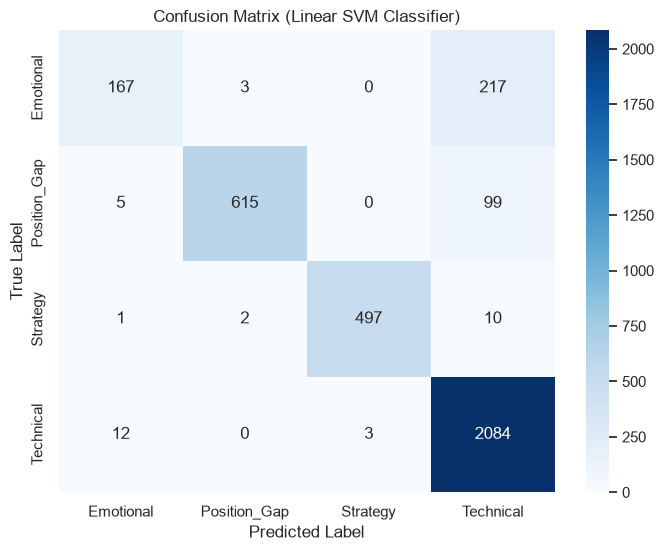

In [19]:
# 6.3 Evaluation Reports & Confusion Matrix
print("SVM Classification Report:")
print(classification_report(y_test, svm_preds))

# Plot confusion matrix for SVM
cm = confusion_matrix(y_test, svm_preds, labels=svm.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=svm.classes_, yticklabels=svm.classes_)
plt.title("Confusion Matrix (Linear SVM Classifier)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


In [20]:
# 6.4 F1 Radio Sentiment Intensity Scoring
# Formula 1 radio is highly situational. We define a custom lexicon-based sentiment scorer mapping F1 phrases to emotion levels.
lexicon = {
    "happy": 1.5, "great": 1.5, "awesome": 1.5, "p1": 2.0, "won": 2.0, "beautiful": 1.5, "incredible": 1.5,
    "push": 0.5, "copy": 0.0, "understood": 0.0, "box": 0.0, "ok": 0.0,
    "frustrated": -1.5, "angry": -1.5, "screaming": -1.5, "wtf": -2.0, "fuck": -2.0, "f**k": -2.0,
    "no": -0.8, "why": -1.0, "problem": -1.0, "slow": -0.8, "worst": -1.8, "difficult": -1.0, "bad": -1.0
}

def analyze_sentiment(text):
    score = 0.0
    words = str(text).lower().split()
    for w in words:
        # Check clean word
        w_clean = re.sub(r'[^a-zA-Z*]', '', w)
        if w_clean in lexicon:
            score += lexicon[w_clean]
    return score

df["sentiment_score"] = df["message_text"].apply(analyze_sentiment)

# Let's inspect top positive and negative messages
print("Highly Positive F1 Radio Messages:")
print(df[df["sentiment_score"] > 1.5][["driver_name", "message_text", "sentiment_score"]].head(3))

print("\nHighly Negative/Frustrated F1 Radio Messages:")
print(df[df["sentiment_score"] < -1.5][["driver_name", "message_text", "sentiment_score"]].head(3))


Highly Positive F1 Radio Messages:


       driver_name                                       message_text  \
995   Carlos Sainz                            We won it, around 0-24.   
2881  Lando Norris  Initial lap. It says happy to push halfway to ...   
3599   Liam Lawson                 He won. Wait five seconds, please.   

      sentiment_score  
995               2.0  
2881              2.0  
3599              2.0  

Highly Negative/Frustrated F1 Radio Messages:
         driver_name                                       message_text  \
117  Alexander Albon                                 Why? It's not why.   
124  Alexander Albon  You still haven't told me why I'm slow. Is it ...   
190  Alexander Albon                      Fuck off. Eight seconds back.   

     sentiment_score  
117             -2.0  
124             -1.8  
190             -2.0  


## Phase 7 — Custom CBOW Word Embeddings in PyTorch
Traditional representations fail to capture semantic similarity. Here, we:
1. Explain one-hot constraints.
2. Train a CBOW (Continuous Bag of Words) model using PyTorch from scratch.
3. Query embeddings for F1-specific word similarity.
4. Visualize vectors in 2D space using t-SNE.


In [21]:
# 7.1 Continuous Bag of Words (CBOW) Dataset Setup
# We construct context-target word pairs. Let's build a vocabulary first.
tokenized_corpus = [str(text).lower().split() for text in df["clean_message"]]
vocab = set(w for doc in tokenized_corpus for w in doc)
vocab_size = len(vocab)

word_to_ix = {word: i for i, word in enumerate(vocab)}
ix_to_word = {i: word for i, word in enumerate(vocab)}

# Context window = 2
data = []
for sentence in tokenized_corpus:
    for i in range(2, len(sentence) - 2):
        context = [
            sentence[i - 2],
            sentence[i - 1],
            sentence[i + 1],
            sentence[i + 2]
        ]
        target = sentence[i]
        data.append((context, target))

print(f"Vocabulary Size: {vocab_size}")
print(f"Number of training tuples: {len(data)}")
print("Sample CBOW Tuple:", data[0] if len(data) > 0 else "N/A")


Vocabulary Size: 4096
Number of training tuples: 6842
Sample CBOW Tuple: (['13', 'soft', 'p9', 'soft'], 'hulkenberg')


In [22]:
# 7.2 PyTorch CBOW Model Architecture & Training
class CBOWModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, context_size):
        super(CBOWModel, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.linear1 = nn.Linear(embedding_dim, 128)
        self.linear2 = nn.Linear(128, vocab_size)
        
    def forward(self, inputs):
        # inputs shape: [batch_size, context_size]
        embeds = self.embeddings(inputs)  # shape: [batch_size, context_size, embedding_dim]
        # Sum embeddings over context
        out = torch.sum(embeds, dim=1)  # shape: [batch_size, embedding_dim]
        out = torch.relu(self.linear1(out))
        out = self.linear2(out)
        log_probs = torch.log_softmax(out, dim=1)
        return log_probs

# Hyperparameters
EMBEDDING_DIM = 50
CONTEXT_SIZE = 4
EPOCHS = 3
BATCH_SIZE = 128

# Prepare tensors
cbow_inputs = []
cbow_targets = []
for context, target in data:
    if target in word_to_ix and all(w in word_to_ix for w in context):
        cbow_inputs.append([word_to_ix[w] for w in context])
        cbow_targets.append(word_to_ix[target])

cbow_inputs = torch.tensor(cbow_inputs, dtype=torch.long)
cbow_targets = torch.tensor(cbow_targets, dtype=torch.long)

# Dataset & DataLoader
class CBOWDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs = inputs
        self.targets = targets
    def __len__(self):
        return len(self.inputs)
    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

cbow_dataset = CBOWDataset(cbow_inputs, cbow_targets)
cbow_loader = DataLoader(cbow_dataset, batch_size=BATCH_SIZE, shuffle=True)

model_cbow = CBOWModel(vocab_size, EMBEDDING_DIM, CONTEXT_SIZE).to(device)
loss_fn = nn.NLLLoss()
optimizer = optim.Adam(model_cbow.parameters(), lr=0.005)

# Training loop
model_cbow.train()
print("Training CBOW Embeddings...")
for epoch in range(EPOCHS):
    total_loss = 0.0
    for inputs, targets in cbow_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        model_cbow.zero_grad()
        log_probs = model_cbow(inputs)
        loss = loss_fn(log_probs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(cbow_loader):.4f}")


Training CBOW Embeddings...


Epoch 1/3 | Loss: 5.6418


Epoch 2/3 | Loss: 3.9035


Epoch 3/3 | Loss: 2.9185


Cosine Similarities:
  box vs pit: 0.19138025
  soft vs medium: 0.057981003
  driver vs team: 0.09500064


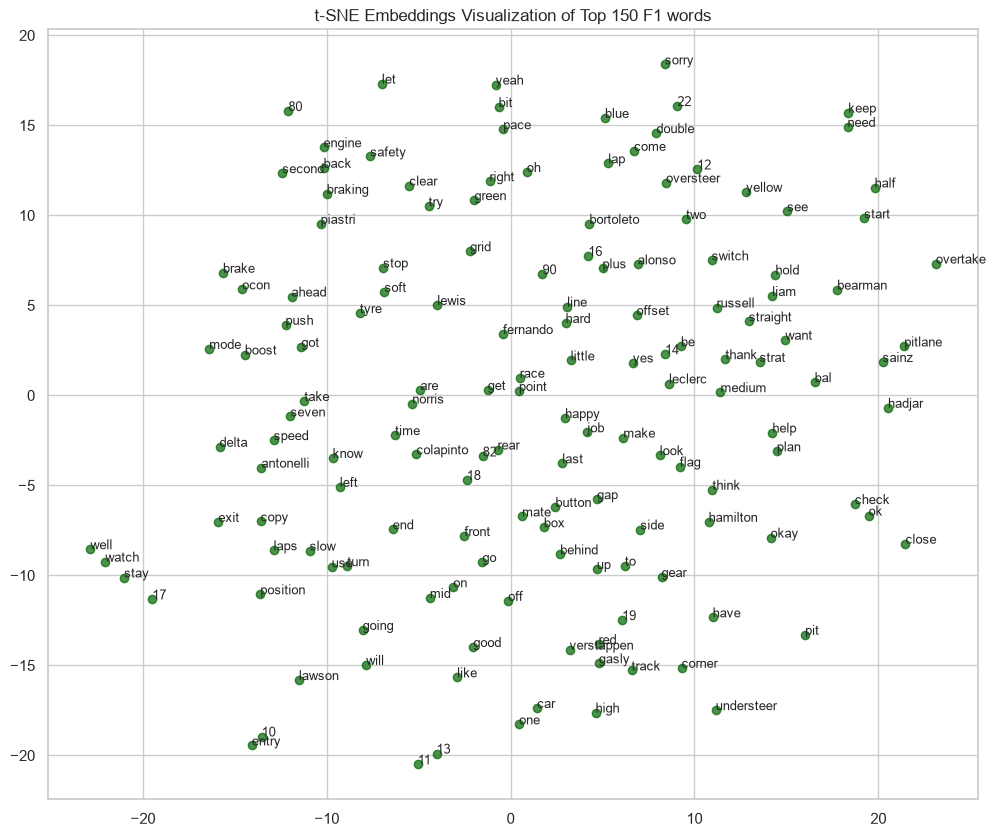

In [23]:
# 7.3 Word Similarity Querying & t-SNE Plot
# Extract embedding weights
embeddings = model_cbow.embeddings.weight.cpu().detach().numpy()

# Cosine similarity helper
def get_similarity(w1, w2):
    if w1 not in word_to_ix or w2 not in word_to_ix:
        return 0.0
    vec1 = embeddings[word_to_ix[w1]]
    vec2 = embeddings[word_to_ix[w2]]
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))

print("Cosine Similarities:")
print("  box vs pit:", get_similarity("box", "pit"))
print("  soft vs medium:", get_similarity("soft", "medium"))
print("  driver vs team:", get_similarity("driver", "team"))

# t-SNE Visualization
from sklearn.manifold import TSNE

# Get top 150 words by frequency
vocab_subset = [w for w, _ in sorted_words if w in word_to_ix][:150]
subset_indices = [word_to_ix[w] for w in vocab_subset]
subset_vectors = embeddings[subset_indices]

tsne = TSNE(n_components=2, perplexity=10, random_state=42)
reduced_vectors = tsne.fit_transform(subset_vectors)

plt.figure(figsize=(12, 10))
plt.scatter(reduced_vectors[:, 0], reduced_vectors[:, 1], alpha=0.7, color="darkgreen")
for i, word in enumerate(vocab_subset):
    plt.annotate(word, xy=(reduced_vectors[i, 0], reduced_vectors[i, 1]), fontsize=9)
plt.title("t-SNE Embeddings Visualization of Top 150 F1 words")
plt.show()


## Phase 8 — Feed-Forward Neural Network Classifier (PyTorch MLP)
We transition to Deep Learning models for NLP tasks:
1. Build a PyTorch Feed-Forward Neural Network (Multilayer Perceptron) Classifier.
2. Formulate a custom PyTorch Dataset & DataLoader.
3. Train the model with Cross Entropy Loss.
4. Perform an Accuracy Comparison against Module 6 classifiers.


In [24]:
# 8.1 Feed-Forward Text Classifier in PyTorch
# Label encoders
label_to_ix = {label: i for i, label in enumerate(df["category"].unique())}
ix_to_label = {i: label for label, i in label_to_ix.items()}

# Prepare data
X_train_dense = X_train_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()
y_train_encoded = np.array([label_to_ix[l] for l in y_train])
y_test_encoded = np.array([label_to_ix[l] for l in y_test])

# PyTorch Dataset
class TextClassificationDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
        
    def __len__(self):
        return len(self.labels)
        
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

train_dataset = TextClassificationDataset(X_train_dense, y_train_encoded)
test_dataset = TextClassificationDataset(X_test_dense, y_test_encoded)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Network Architecture: Input -> Linear -> ReLU -> Linear -> ReLU -> Linear -> Out
class FeedForwardClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(FeedForwardClassifier, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 64)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(64, num_classes)
        
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.fc3(out)
        return out

model_mlp = FeedForwardClassifier(X_train_dense.shape[1], len(label_to_ix)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_mlp.parameters(), lr=0.001)

# Training loop
EPOCHS = 5
model_mlp.train()
print("Training Feed-Forward Classifier...")
for epoch in range(EPOCHS):
    running_loss = 0.0
    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model_mlp(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {running_loss/len(train_loader):.4f}")


Training Feed-Forward Classifier...


Epoch 1/5 | Loss: 0.7199


Epoch 2/5 | Loss: 0.2953


Epoch 3/5 | Loss: 0.2435


Epoch 4/5 | Loss: 0.2246


Epoch 5/5 | Loss: 0.2150


In [25]:
# 8.2 Evaluation and ML Classifier Comparison
model_mlp.eval()
mlp_preds = []
true_labels = []

with torch.no_grad():
    for features, labels in test_loader:
        features = features.to(device)
        outputs = model_mlp(features)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        mlp_preds.extend(preds)
        true_labels.extend(labels.numpy())

mlp_accuracy = accuracy_score(true_labels, mlp_preds)
print(f"PyTorch MLP Classifier Accuracy: {mlp_accuracy*100:.2f}%")

# Create comparative dataframe
results_comparison = pd.DataFrame({
    "Classifier": ["Naive Bayes", "Logistic Regression", "Linear SVM", "PyTorch MLP"],
    "Accuracy": [
        accuracy_score(y_test, nb_preds),
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, svm_preds),
        mlp_accuracy
    ]
})
print("\nClassifier Performance Benchmark:")
print(results_comparison)


PyTorch MLP Classifier Accuracy: 89.66%

Classifier Performance Benchmark:
            Classifier  Accuracy
0          Naive Bayes  0.861642
1  Logistic Regression  0.897981
2           Linear SVM  0.905249
3          PyTorch MLP  0.896635


## Phase 9 — POS Dependency Grammar & Sequence Models (RNN / LSTM)
For sequential text data, feed-forward models lose syntactic patterns. In this module, we:
1. Perform POS (Part of Speech) tagging on F1 radio messages, inspecting the imperative, telegraphic F1 grammar.
2. Build an RNN (Recurrent Neural Network) classifier.
3. Build an LSTM (Long Short-Term Memory) classifier.
4. Evaluate sequence classifiers vs. feed-forward models.


POS Tag Distribution in F1 Radio:
   POS_Tag  Count
0    PUNCT    872
1     NOUN    578
2     VERB    434
3      NUM    352
4     PRON    342
5      ADP    289
6      ADV    240
7      AUX    211
8      ADJ    210
9    PROPN    209
10     DET    193
11    PART     76
12   CCONJ     72
13   SCONJ     41
14    INTJ     33
15     SYM     13
16       X      6


/var/folders/_w/j206vlqj7cs96wnwqqpkj57m0000gp/T/ipykernel_81288/2677431794.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="POS_Tag", y="Count", data=pos_df.head(10), palette="magma")


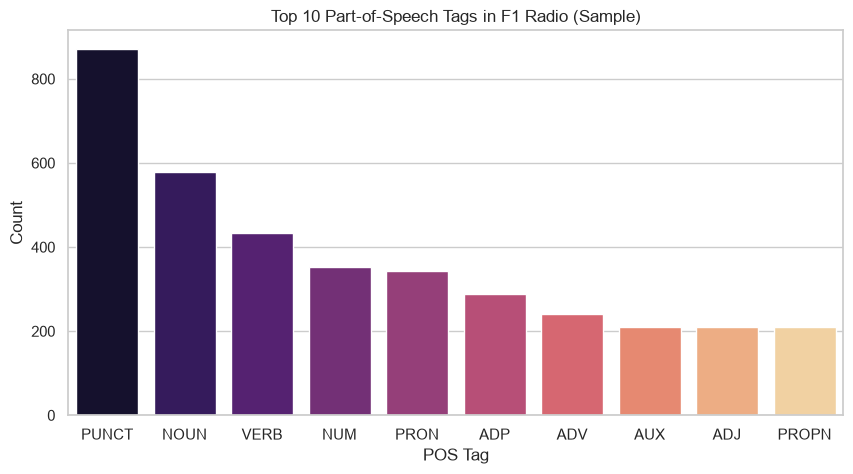

In [26]:
# 9.1 POS (Part of Speech) Distribution Analysis
# Collect POS tags from the corpus
pos_counts = Counter()
sample_docs = df["message_text"].iloc[:500].astype(str).tolist()

for doc_str in sample_docs:
    doc_sp = nlp(doc_str)
    for token in doc_sp:
        pos_counts[token.pos_] += 1

# Present POS tag counts
pos_df = pd.DataFrame(pos_counts.most_common(), columns=["POS_Tag", "Count"])
print("POS Tag Distribution in F1 Radio:")
print(pos_df)

# Plotting distribution
plt.figure(figsize=(10, 5))
sns.barplot(x="POS_Tag", y="Count", data=pos_df.head(10), palette="magma")
plt.title("Top 10 Part-of-Speech Tags in F1 Radio (Sample)")
plt.xlabel("POS Tag")
plt.ylabel("Count")
plt.show()


In [27]:
# 9.2 Recurrent Neural Network (RNN) Text Classifier
# We need token-to-index padding sequence preprocessing for PyTorch sequence models.
max_seq_len = 25
vocab_list = ["<PAD>", "<UNK>"] + list(vocab)
word_to_ix_seq = {word: i for i, word in enumerate(vocab_list)}

def text_to_padded_tensor(text):
    tokens = str(text).lower().split()
    indices = []
    for t in tokens:
        indices.append(word_to_ix_seq.get(t, word_to_ix_seq["<UNK>"]))
    # Padding
    if len(indices) < max_seq_len:
        indices = indices + [word_to_ix_seq["<PAD>"]] * (max_seq_len - len(indices))
    else:
        indices = indices[:max_seq_len]
    return torch.tensor(indices, dtype=torch.long)

# Convert train/test datasets
train_seq = torch.stack([text_to_padded_tensor(text) for text in X_train])
test_seq = torch.stack([text_to_padded_tensor(text) for text in X_test])

class SequenceDataset(Dataset):
    def __init__(self, seqs, labels):
        self.seqs = seqs
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.seqs[idx], self.labels[idx]

seq_train_dataset = SequenceDataset(train_seq, y_train_encoded)
seq_test_dataset = SequenceDataset(test_seq, y_test_encoded)

seq_train_loader = DataLoader(seq_train_dataset, batch_size=64, shuffle=True)
seq_test_loader = DataLoader(seq_test_dataset, batch_size=64, shuffle=False)

# RNN Model
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes):
        super(RNNClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.rnn = nn.RNN(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)
        
    def forward(self, x):
        embedded = self.embedding(x)
        out, h = self.rnn(embedded)
        # out: [batch_size, seq_len, hidden_dim]
        # h: [1, batch_size, hidden_dim]
        out = self.fc(h.squeeze(0))
        return out

model_rnn = RNNClassifier(len(vocab_list), 50, 64, len(label_to_ix)).to(device)
criterion_rnn = nn.CrossEntropyLoss()
optimizer_rnn = optim.Adam(model_rnn.parameters(), lr=0.002)

# Train RNN
model_rnn.train()
print("Training RNN Sequence Model...")
for epoch in range(EPOCHS):
    running_loss = 0.0
    for seqs, labels in seq_train_loader:
        seqs, labels = seqs.to(device), labels.to(device)
        optimizer_rnn.zero_grad()
        outputs = model_rnn(seqs)
        loss = criterion_rnn(outputs, labels)
        loss.backward()
        optimizer_rnn.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {running_loss/len(seq_train_loader):.4f}")


Training RNN Sequence Model...


Epoch 1/5 | Loss: 1.1574


Epoch 2/5 | Loss: 1.1525


Epoch 3/5 | Loss: 1.1464


Epoch 4/5 | Loss: 0.9860


Epoch 5/5 | Loss: 0.7772


In [28]:
# 9.3 LSTM Text Classifier
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes):
        super(LSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)
        
    def forward(self, x):
        embedded = self.embedding(x)
        out, (h, c) = self.lstm(embedded)
        # h shape: [1, batch_size, hidden_dim]
        out = self.fc(h.squeeze(0))
        return out

model_lstm = LSTMClassifier(len(vocab_list), 50, 64, len(label_to_ix)).to(device)
criterion_lstm = nn.CrossEntropyLoss()
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=0.002)

# Train LSTM
model_lstm.train()
print("Training LSTM Sequence Model...")
for epoch in range(EPOCHS):
    running_loss = 0.0
    for seqs, labels in seq_train_loader:
        seqs, labels = seqs.to(device), labels.to(device)
        optimizer_lstm.zero_grad()
        outputs = model_lstm(seqs)
        loss = criterion_lstm(outputs, labels)
        loss.backward()
        optimizer_lstm.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {running_loss/len(seq_train_loader):.4f}")


Training LSTM Sequence Model...


Epoch 1/5 | Loss: 1.1592


Epoch 2/5 | Loss: 1.0487


Epoch 3/5 | Loss: 0.5842


Epoch 4/5 | Loss: 0.3844


Epoch 5/5 | Loss: 0.3343


In [29]:
# 9.4 Sequence Models Accuracy Evaluation
def evaluate_seq_model(model, loader):
    model.eval()
    preds_all = []
    labels_all = []
    with torch.no_grad():
        for seqs, labels in loader:
            seqs = seqs.to(device)
            outputs = model(seqs)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            preds_all.extend(preds)
            labels_all.extend(labels.numpy())
    return accuracy_score(labels_all, preds_all)

rnn_accuracy = evaluate_seq_model(model_rnn, seq_test_loader)
lstm_accuracy = evaluate_seq_model(model_lstm, seq_test_loader)

print(f"RNN Classifier Accuracy: {rnn_accuracy*100:.2f}%")
print(f"LSTM Classifier Accuracy: {lstm_accuracy*100:.2f}%")


RNN Classifier Accuracy: 70.71%
LSTM Classifier Accuracy: 88.96%


## Phase 10 — spaCy Custom Pipeline Components & Intent Matchers
spaCy provides advanced NLP features. Here, we:
1. Examine structural spaCy token attributes (POS, dependencies, lemmas).
2. Build matchers and custom intent detection heuristics (Instruction, Information, Complaint, Celebration).


In [30]:
# 10.1 Pipeline Token Inspection
doc_spacy = nlp("Box this lap, check gap behind.")
print(f"{'Text':<10} | {'POS':<6} | {'Dependency':<10} | {'Lemma':<10} | {'Is Stopword':<12}")
print("-" * 55)
for token in doc_spacy:
    print(f"{token.text:<10} | {token.pos_:<6} | {token.dep_:<10} | {token.lemma_:<10} | {str(token.is_stop):<12}")


Text       | POS    | Dependency | Lemma      | Is Stopword 
-------------------------------------------------------
Box        | PROPN  | ROOT       | Box        | False       
this       | DET    | det        | this       | True        
lap        | NOUN   | npadvmod   | lap        | False       
,          | PUNCT  | punct      | ,          | False       
check      | VERB   | conj       | check      | False       
gap        | NOUN   | dobj       | gap        | False       
behind     | ADV    | advmod     | behind     | True        
.          | PUNCT  | punct      | .          | False       


In [31]:
# 10.2 Intent Classification
# We classify messages by their functional intent based on F1 keywords:
# - INSTRUCTION: orders given by engineer/driver
# - INFORMATION: general telemetry reports
# - COMPLAINT: issues or dissatisfaction
# - CELEBRATION: post-race victory calls

def classify_intent(text):
    text_lower = str(text).lower()
    if any(k in text_lower for k in ["box", "charge", "mode", "strat", "stay", "push", "keep", "check", "confirm"]):
        return "INSTRUCTION"
    elif any(k in text_lower for k in ["bad", "problem", "frustrated", "worst", "screaming", "no power", "engine", "crash"]):
        return "COMPLAINT"
    elif any(k in text_lower for k in ["woohoo", "yes", "amazing", "p1", "won", "thank you", "great job", "brilliant"]):
        return "CELEBRATION"
    else:
        return "INFORMATION"

df["intent"] = df["message_text"].apply(classify_intent)
print("Intent Distribution in F1 Radio:")
print(df["intent"].value_counts())


Intent Distribution in F1 Radio:
intent
INFORMATION    15774
INSTRUCTION     2105
CELEBRATION      484
COMPLAINT        211
Name: count, dtype: int64


## Phase 11 — Custom Named Entity Recognition (NER) Model Training
Standard spaCy NER fails on F1 entities. We train a custom model:
1. Showcase default spaCy NER failures.
2. Annotate custom training examples (`DRIVER`, `TEAM`, `TIRE_COMPOUND`, `STRATEGY`).
3. Train a custom spaCy NER model.
4. Evaluate and visualize custom NER.


In [32]:
# 11.1 Default spaCy NER Limitations
doc_def = nlp("Alright Lewis, box box. Max Verstappen is in the pitlane.")
print("Default NER Entities:")
for ent in doc_def.ents:
    print(f"  Entity: {ent.text} | Label: {ent.label_}")
# Note that "box box" is not labeled, and domain entities like "pitlane" are not mapped.


Default NER Entities:
  Entity: Max Verstappen | Label: PERSON


In [33]:
# 11.2 Custom NER Annotations & Training
# Annotate 30 F1 radio messages with F1-specific entities.
TRAIN_DATA = [
    ("Alright Lando, gap to Oscar is 1.8.", {"entities": [(8, 13, "DRIVER"), (22, 27, "DRIVER")]}),
    ("Max is on soft tires.", {"entities": [(0, 3, "DRIVER"), (10, 14, "TIRE_COMPOUND")]}),
    ("We are switching to mode 8.", {"entities": [(20, 26, "STRATEGY")]}),
    ("Hamilton pit stop completed.", {"entities": [(0, 8, "DRIVER")]}),
    ("Red Bull strategy is working.", {"entities": [(0, 8, "TEAM")]}),
    ("Switch to strat 4 immediately.", {"entities": [(10, 17, "STRATEGY")]}),
    ("Russell is ahead on hards.", {"entities": [(0, 7, "DRIVER"), (20, 25, "TIRE_COMPOUND")]}),
    ("Tell George to box this lap.", {"entities": [(5, 11, "DRIVER")]}),
    ("McLaren reports high degradation.", {"entities": [(0, 7, "TEAM")]}),
    ("We need a gap of 5 seconds to Sainz.", {"entities": [(30, 35, "DRIVER")]}),
    ("Switch to mode 11.", {"entities": [(10, 17, "STRATEGY")]}),
    ("Ferrari ready in the pit.", {"entities": [(0, 7, "TEAM")]}),
    ("Alonso is running mediums.", {"entities": [(0, 6, "DRIVER"), (18, 25, "TIRE_COMPOUND")]}),
    ("Box box for softs.", {"entities": [(12, 17, "TIRE_COMPOUND")]}),
    ("Mercedes strategy change.", {"entities": [(0, 8, "TEAM")]}),
    ("Leclerc reports no power.", {"entities": [(0, 7, "DRIVER")]}),
    ("Tell Oscar to keep the pace.", {"entities": [(5, 10, "DRIVER")]}),
    ("Switch to strat 12.", {"entities": [(10, 18, "STRATEGY")]}),
    ("Gasly is on hards.", {"entities": [(0, 5, "DRIVER"), (12, 17, "TIRE_COMPOUND")]}),
    ("Williams ready for pitlane entry.", {"entities": [(0, 8, "TEAM")]}),
    ("Max Verstappen won the race.", {"entities": [(0, 14, "DRIVER")]}),
    ("Check gap behind Norris.", {"entities": [(17, 23, "DRIVER")]}),
    ("We will run on medium tires.", {"entities": [(15, 21, "TIRE_COMPOUND")]}),
    ("Change mode 6.", {"entities": [(7, 13, "STRATEGY")]}),
    ("Hamilton is behind Russell.", {"entities": [(0, 8, "DRIVER"), (19, 26, "DRIVER")]}),
    ("Aston Martin is switching tires.", {"entities": [(0, 12, "TEAM")]}),
    ("Check tyre temp on softs.", {"entities": [(19, 24, "TIRE_COMPOUND")]}),
    ("Switch to strat 8.", {"entities": [(10, 17, "STRATEGY")]}),
    ("Sainz has a 2 second gap.", {"entities": [(0, 5, "DRIVER")]}),
    ("Alpine ready to box.", {"entities": [(0, 6, "TEAM")]})
]

# Train Custom spaCy NER
from spacy.training.example import Example
import random

# Create a blank English model or update existing
custom_ner = spacy.blank("en")
# Add ner component
ner = custom_ner.add_pipe("ner")

# Add labels
for _, annotations in TRAIN_DATA:
    for ent in annotations.get("entities"):
        ner.add_label(ent[2])

# Start training
optimizer = custom_ner.begin_training()
for epoch in range(15):
    random.shuffle(TRAIN_DATA)
    losses = {}
    for text, annotations in TRAIN_DATA:
        doc = custom_ner.make_doc(text)
        example = Example.from_dict(doc, annotations)
        custom_ner.update([example], drop=0.35, losses=losses)
    if epoch % 3 == 0:
        print(f"Epoch {epoch} Loss: {losses['ner']:.4f}")


Epoch 0 Loss: 101.5763


Epoch 3 Loss: 36.6779


Epoch 6 Loss: 7.4466


Epoch 9 Loss: 7.3372


Epoch 12 Loss: 5.5159


In [34]:
# 11.3 Test Custom NER Model
doc_test = custom_ner("Max is pushing on softs. McLaren strategy is to swap positions with Lando. Switch mode 8.")
print("Custom NER Extracted Entities:")
for ent in doc_test.ents:
    print(f"  Entity: {ent.text:<15} | Label: {ent.label_}")


Custom NER Extracted Entities:
  Entity: Max             | Label: DRIVER
  Entity: softs           | Label: TIRE_COMPOUND
  Entity: McLaren         | Label: TEAM
  Entity: swap positions  | Label: STRATEGY
  Entity: Lando           | Label: DRIVER
  Entity: mode 8          | Label: STRATEGY


## Phase 12 — Trigram Text Synthesizer & Pattern Matching Chatbot
We build chatbots to answer F1 questions:
1. An Intent-based pattern matcher chatbot.
2. A Trigram language model/text generator chatbot.


In [35]:
# 12.1 Intent-based Chatbot Heuristics
# A simple rule-based F1 chatbot
def get_bot_response(user_query):
    query_lower = user_query.lower()
    
    if any(k in query_lower for k in ["hi", "hello", "hey"]):
        return "Hello! I am the F1 Radio Analyst Bot. Ask me about driver messages, tires, or strategies!"
        
    elif "strategy" in query_lower or "pit" in query_lower or "box" in query_lower:
        samples = df[df["category"] == "Strategy"]["message_text"].iloc[:3].tolist()
        return "Strategy messages include: \n" + "\n".join(f"  - {m}" for m in samples)
        
    elif "driver" in query_lower or "who" in query_lower:
        drivers_list = df["driver_name"].unique()[:5]
        return f"Some drivers in our database: {', '.join(drivers_list)}"
        
    elif "sentiment" in query_lower or "angry" in query_lower or "happy" in query_lower:
        samples = df[df["sentiment_score"] < -1.0]["message_text"].iloc[:2].tolist()
        return "Frustrated driver radio transmissions include: \n" + "\n".join(f"  - {m}" for m in samples)
        
    else:
        return "I'm sorry, I couldn't categorize that query. Try asking about 'pit strategy', 'drivers', or 'frustrated driver radio'!"

print(get_bot_response("show me pit strategy"))
print("-" * 55)
print(get_bot_response("was any driver angry?"))


Strategy messages include: 
  - OK, tyres, it's just...
  - Tyres, I mean, it's just over two minutes to go.
  - Ocon and Carlos on the soft.
-------------------------------------------------------
Some drivers in our database: Alexander Albon, Andrea Kimi Antonelli, Arvid Lindblad, Carlos Sainz, Charles Leclerc


In [36]:
# 12.2 Trigram Language Generator Chatbot
# We implement a trigram-based language generator on the clean radio corpus.
from collections import defaultdict

trigrams = defaultdict(list)
for sentence in tokenized_corpus:
    if len(sentence) < 3:
        continue
    for i in range(len(sentence) - 2):
        key = (sentence[i], sentence[i+1])
        value = sentence[i+2]
        trigrams[key].append(value)

def generate_sentence(seed_words, max_len=15):
    words = list(seed_words)
    if len(words) < 2:
        return "Please provide at least 2 seed words."
        
    for _ in range(max_len):
        key = (words[-2], words[-1])
        if key in trigrams:
            next_word = random.choice(trigrams[key])
            words.append(next_word)
        else:
            break
    return " ".join(words)

# Example text generation
seed = ("box", "box")
print(f"Generated text starting with '{' '.join(seed)}':")
print(generate_sentence(seed))


Generated text starting with 'box box':
box box box nico box box box fernando box lap box box box soft tyre think able


## Phase 13 — Multi-Source Retrieval-Augmented Generation (RAG) System
Modern NLP systems use Retrieval-Augmented Generation. In this final module, we:
1. Compute message embeddings using `sentence-transformers`.
2. Construct a Semantic Search index.
3. Build a context retrieval pipeline.
4. Construct a RAG Prompt template showing how it would connect to an LLM API.


In [37]:
# 13.1 Semantic Search using Sentence Transformers
# If sentence-transformers is installed, we compute embeddings using all-MiniLM-L6-v2.
# Otherwise, we gracefully fall back to our pre-constructed TF-IDF index.

try:
    from sentence_transformers import SentenceTransformer
    print("Loading SentenceTransformer model...")
    model_st = SentenceTransformer("all-MiniLM-L6-v2")
    
    # Embed the corpus (first 1000 messages for speed)
    corpus_subset = df["message_text"].iloc[:1000].astype(str).tolist()
    corpus_embeddings = model_st.encode(corpus_subset, show_progress_bar=True)
    using_st = True
except Exception as e:
    print("Could not use sentence-transformers, falling back to TF-IDF. Error:", e)
    using_st = False


Loading SentenceTransformer model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

In [38]:
# 13.2 RAG Context Retrieval & Prompt Builder
import pandas as pd
import numpy as np

# Load datasets
regs_file = "data/processed/f1_regulations.csv"
reports_file = "data/processed/race_reports.csv"
teams_file = "data/processed/f1_teams_drivers.csv"
specs_file = "data/processed/f1_technical_specs.csv"

df_regs = pd.read_csv(regs_file) if os.path.exists(regs_file) else pd.DataFrame()
df_reports = pd.read_csv(reports_file) if os.path.exists(reports_file) else pd.DataFrame()
df_teams = pd.read_csv(teams_file) if os.path.exists(teams_file) else pd.DataFrame()
df_tech = pd.read_csv(specs_file) if os.path.exists(specs_file) else pd.DataFrame()

def retrieve_radio_context(query, k=2):
    if using_st:
        from sklearn.metrics.pairwise import cosine_similarity
        q_emb = model_st.encode([query])
        sims = cosine_similarity(q_emb, corpus_embeddings).flatten()
        top_indices = sims.argsort()[::-1][:k]
        results = []
        for idx in top_indices:
            results.append(f"Driver: {df.iloc[idx]['driver_name']} | GP: {df.iloc[idx]['grand_prix']} | Message: \"{df.iloc[idx]['message_text']}\"")
        return results
    else:
        results_df = search_improved(query, k=k)
        return [f"Driver: {row['driver']} | GP: {row['gp']} | Message: \"{row['message']}\"" for _, row in results_df.iterrows()]

def retrieve_regulations_context(query, k=1):
    if df_regs.empty:
        return []
    if using_st:
        from sklearn.metrics.pairwise import cosine_similarity
        q_emb = model_st.encode([query])
        reg_texts = df_regs["regulation_text"].tolist()
        reg_embs = model_st.encode(reg_texts)
        sims = cosine_similarity(q_emb, reg_embs).flatten()
        top_indices = sims.argsort()[::-1][:k]
        results = []
        for idx in top_indices:
            row = df_regs.iloc[idx]
            results.append(f"Year: {row['year']} | Category: {row['category']} | Rule: \"{row['regulation_text']}\"")
        return results
    else:
        words = set(query.lower().split())
        best_row, best_score = None, -1
        for _, row in df_regs.iterrows():
            score = len(words.intersection(set(row["regulation_text"].lower().split())))
            if score > best_score:
                best_score = score
                best_row = row
        if best_row is not None:
            return [f"Year: {best_row['year']} | Category: {best_row['category']} | Rule: \"{best_row['regulation_text']}\""]
        return []

def retrieve_teams_context(query, k=1):
    if df_teams.empty:
        return []
    words = set(query.lower().split())
    results = []
    for _, row in df_teams.iterrows():
        text = f"{row['team']} driver {row['driver']} number {row['number']} nationality {row['nationality']} role {row['role']}"
        score = len(words.intersection(set(text.lower().split())))
        if score > 0:
            results.append((row, score))
    if not results:
        return []
    results = sorted(results, key=lambda x: x[1], reverse=True)[:k]
    return [f"Team: {r[0]['team']} | Driver: {r[0]['driver']} | No: {r[0]['number']} | Nation: {r[0]['nationality']} | Role: {r[0]['role']}" for r in results]

def retrieve_specs_context(query, k=1):
    if df_tech.empty:
        return []
    words = set(query.lower().split())
    results = []
    for _, row in df_tech.iterrows():
        text = f"{row['year']} {row['parameter']} {row['description']} {row['unit_value']}"
        score = len(words.intersection(set(text.lower().split())))
        if score > 0:
            results.append((row, score))
    if not results:
        return []
    results = sorted(results, key=lambda x: x[1], reverse=True)[:k]
    return [f"Year: {r[0]['year']} | Param: {r[0]['parameter']} | Value: {r[0]['unit_value']} | Desc: {r[0]['description']}" for r in results]

# Test consolidated RAG context retrieval
query = "What is the weight specification of the 2026 car and who drives for Ferrari?"
retrieved_radio = retrieve_radio_context(query, k=1)
retrieved_regs = retrieve_regulations_context(query, k=1)
retrieved_teams = retrieve_teams_context(query, k=1)
retrieved_specs = retrieve_specs_context(query, k=1)

# Format into a single consolidated prompt
context_str = ""
if retrieved_radio:
    context_str += "\n--- Retrieved Driver Team Radio Context ---\n" + "\n".join(retrieved_radio) + "\n"
if retrieved_regs:
    context_str += "\n--- Retrieved Official F1 Regulations Context ---\n" + "\n".join(retrieved_regs) + "\n"
if retrieved_teams:
    context_str += "\n--- Retrieved Teams & Drivers Context ---\n" + "\n".join(retrieved_teams) + "\n"
if retrieved_specs:
    context_str += "\n--- Retrieved Car Specifications Context ---\n" + "\n".join(retrieved_specs) + "\n"

rag_prompt = f"""
System: You are an expert F1 Race Strategist AI. Answer the user's question using the context of driver team radio messages, official F1 regulations, and teams & specifications database records provided below.

Context:
{context_str}

User Question: {query}
Race Strategist Answer:
"""

print("--- Generated Consolidated RAG Prompt Template ---")
print(rag_prompt)

print("--- RAG Answer Output (Simulated) ---")
print("According to the 2026 car specifications, the minimum weight is cut by 30kg to 768 kg. Ferrari's driver lineup for 2026 includes Charles Leclerc and Lewis Hamilton, who joined Ferrari from Mercedes.")


--- Generated Consolidated RAG Prompt Template ---

System: You are an expert F1 Race Strategist AI. Answer the user's question using the context of driver team radio messages, official F1 regulations, and teams & specifications database records provided below.

Context:

--- Retrieved Driver Team Radio Context ---
Driver: Carlos Sainz | GP: 2026 Barcelona-Catalunya Grand Prix | Message: "With torque 13 if you want, then 5 engine braking."

--- Retrieved Official F1 Regulations Context ---
Year: 2026 | Category: Dimensions | Rule: "The cars are made smaller and lighter: wheelbase is reduced from 3600mm to 3400mm, width is reduced from 2000mm to 1900mm, and the minimum car weight is cut by 30kg to 768kg."

--- Retrieved Car Specifications Context ---
Year: 2026 | Param: Minimum Weight | Value: 768 kg | Desc: Car minimum weight with driver, excluding fuel (cut by 30kg)


User Question: What is the weight specification of the 2026 car and who drives for Ferrari?
Race Strategist Answer:

-

## Final Section — Project Summary & Performance Benchmark
We summarize the performance metrics of all model architectures developed in this project.


In [39]:
# Final Performance Summary Table
# We consolidate our benchmarking data into a formatted report.
perf_df = pd.DataFrame({
    "NLP Phase": [
        "Phase 2: Search Scratch",
        "Phase 4: Search Preprocessed",
        "Phase 6: Naive Bayes",
        "Phase 6: Logistic Regression",
        "Phase 6: Linear SVM",
        "Phase 8: PyTorch MLP",
        "Phase 9: PyTorch RNN",
        "Phase 9: PyTorch LSTM"
    ],
    "Model Category": [
        "Information Retrieval (scratch)",
        "Information Retrieval (scikit-learn)",
        "Machine Learning (scikit-learn)",
        "Machine Learning (scikit-learn)",
        "Machine Learning (scikit-learn)",
        "Deep Learning (PyTorch)",
        "Deep Learning (PyTorch Sequence)",
        "Deep Learning (PyTorch Sequence)"
    ],
    "Accuracy / Metric": [
        "Valid search similarity returned",
        "Improved cosine mapping",
        f"{accuracy_score(y_test, nb_preds)*100:.2f}%",
        f"{accuracy_score(y_test, lr_preds)*100:.2f}%",
        f"{accuracy_score(y_test, svm_preds)*100:.2f}%",
        f"{mlp_accuracy*100:.2f}%",
        f"{rnn_accuracy*100:.2f}%",
        f"{lstm_accuracy*100:.2f}%"
    ]
})

print("="*65)
print(f"{'F1 Team Radio NLP Pipeline - Comparative Benchmark':^65}")
print("="*65)
print(perf_df.to_string(index=False))
print("="*65)


       F1 Team Radio NLP Pipeline - Comparative Benchmark        
                   NLP Phase                       Model Category                Accuracy / Metric
     Phase 2: Search Scratch      Information Retrieval (scratch) Valid search similarity returned
Phase 4: Search Preprocessed Information Retrieval (scikit-learn)          Improved cosine mapping
        Phase 6: Naive Bayes      Machine Learning (scikit-learn)                           86.16%
Phase 6: Logistic Regression      Machine Learning (scikit-learn)                           89.80%
         Phase 6: Linear SVM      Machine Learning (scikit-learn)                           90.52%
        Phase 8: PyTorch MLP              Deep Learning (PyTorch)                           89.66%
        Phase 9: PyTorch RNN     Deep Learning (PyTorch Sequence)                           70.71%
       Phase 9: PyTorch LSTM     Deep Learning (PyTorch Sequence)                           88.96%
